# BMI Prediction with Raw FaceNet + Ridge

This notebook keeps only the final best-performing modeling pipeline:

```text
image -> MTCNN face alignment -> FaceNet/VGGFace2 embedding -> gender feature -> Ridge Regression -> BMI prediction
```

The previous exploratory model variants were removed from this notebook to keep the final run clean and easy to explain.

## 0. Install Dependency

Run this once only if `facenet_pytorch` is missing. Restart the kernel after installation.

In [1]:
# %pip install facenet-pytorch --no-deps

## 1. Imports

In [2]:
from pathlib import Path
import json
import math
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from facenet_pytorch import MTCNN, InceptionResnetV1

from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. Configuration

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)

# MTCNN is kept on CPU because facenet_pytorch MTCNN can crash on Apple MPS for some image sizes.
MTCNN_DEVICE = torch.device("cpu")

QUICK_RUN = False
QUICK_TRAIN_N = 300
QUICK_TEST_N = 120
BATCH_SIZE = 32
USE_GENDER_FEATURE = True

print("Embedding device:", DEVICE)
print("MTCNN device:", MTCNN_DEVICE)
print("QUICK_RUN:", QUICK_RUN)

Embedding device: mps
MTCNN device: cpu
QUICK_RUN: False


## 3. Paths

In [4]:
PROJECT_DIR = Path.cwd()
ROOT_DIR = PROJECT_DIR.parent if PROJECT_DIR.name.lower() == "final project" else PROJECT_DIR

FINAL_DIR = ROOT_DIR / "Final project"
OUTPUT_DIR = FINAL_DIR / "outputs"
FEATURE_DIR = OUTPUT_DIR / "features"
MODEL_DIR = OUTPUT_DIR / "models"

for directory in [OUTPUT_DIR, FEATURE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = OUTPUT_DIR / "bmi_clean_manifest.csv"
assert MANIFEST_PATH.exists(), f"Missing manifest: {MANIFEST_PATH}. Run the EDA notebook first."

print("Manifest:", MANIFEST_PATH)
print("Output dir:", OUTPUT_DIR)

Manifest: /Users/jiayingzhong/Desktop/ML_2/Final project/outputs/bmi_clean_manifest.csv
Output dir: /Users/jiayingzhong/Desktop/ML_2/Final project/outputs


## 4. Load Clean Manifest

In [5]:
df = pd.read_csv(MANIFEST_PATH)
df["image_path"] = df["image_path"].astype(str)
df["gender_code"] = df["gender"].map({"Female": 0, "Male": 1}).astype(float)

train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
test_df = df[df["split"] == "test"].copy().reset_index(drop=True)

if QUICK_RUN:
    train_df = train_df.sample(min(QUICK_TRAIN_N, len(train_df)), random_state=SEED).reset_index(drop=True)
    test_df = test_df.sample(min(QUICK_TEST_N, len(test_df)), random_state=SEED).reset_index(drop=True)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
display(train_df.head())

Train: (3210, 14)
Test: (752, 14)


,row_id,name,image_path,bmi,bmi_category,gender,is_training,split,width,height,mode,aspect_ratio,pixels,gender_code
0,0,img_0.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,34.207396,obese,Male,1,train,164,176,RGB,0.931818,28864,1.0
1,1,img_1.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,26.453720,overweight,Male,1,train,150,173,RGB,0.867052,25950,1.0
2,2,img_2.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,34.967561,obese,Female,1,train,226,251,RGB,0.900398,56726,0.0
3,3,img_3.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,22.044766,normal,Female,1,train,97,126,RGB,0.769841,12222,0.0
4,6,img_6.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,25.845588,overweight,Female,1,train,87,115,RGB,0.756522,10005,0.0


## 5. Evaluation Helpers

In [6]:
def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2 or np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def regression_report(y_true, y_pred):
    return {
        "Pearson_r": pearson_r(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def evaluate_by_gender(frame, pred_col="pred"):
    rows = []
    rows.append({"group": "Overall", "n": len(frame), **regression_report(frame["bmi"], frame[pred_col])})
    for gender, group in frame.groupby("gender"):
        rows.append({"group": gender, "n": len(group), **regression_report(group["bmi"], group[pred_col])})
    return pd.DataFrame(rows).set_index("group").round(4)

## 6. Initialize MTCNN and FaceNet

In [7]:
mtcnn = MTCNN(
    image_size=160,
    margin=20,
    keep_all=False,
    post_process=True,
    device=MTCNN_DEVICE,
)

facenet = InceptionResnetV1(pretrained="vggface2").eval().to(DEVICE)
print("MTCNN and FaceNet/VGGFace2 are ready.")

MTCNN and FaceNet/VGGFace2 are ready.


## 7. Optional Face Alignment Preview

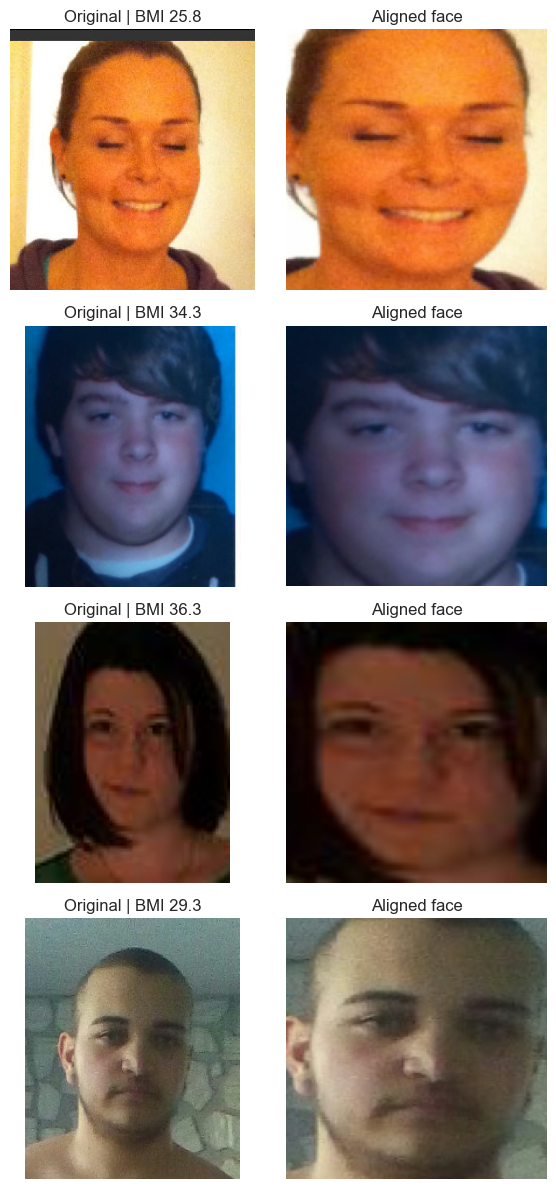

In [8]:
sample = train_df.sample(min(4, len(train_df)), random_state=SEED)
fig, axes = plt.subplots(len(sample), 2, figsize=(6, 3 * len(sample)))
axes = np.array(axes).reshape(-1, 2)

for row_idx, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    face = mtcnn(img)

    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].set_title(f"Original | BMI {row['bmi']:.1f}")
    axes[row_idx, 0].axis("off")

    if face is None:
        axes[row_idx, 1].text(0.5, 0.5, "No face detected", ha="center", va="center")
    else:
        face_img = face.permute(1, 2, 0).cpu().numpy()
        face_img = np.clip((face_img + 1) / 2, 0, 1)
        axes[row_idx, 1].imshow(face_img)
    axes[row_idx, 1].set_title("Aligned face")
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()

## 8. Extract or Load FaceNet Embeddings

In [9]:
@torch.no_grad()
def embed_face_batch(face_tensors):
    batch = torch.stack(face_tensors).to(DEVICE)
    return facenet(batch).cpu().numpy()


def extract_embeddings(frame, batch_size=BATCH_SIZE):
    rows, faces, embeddings = [], [], []
    failed = []
    start = time.time()

    for idx, row in frame.iterrows():
        img = Image.open(row["image_path"]).convert("RGB")
        face = mtcnn(img)

        if face is None:
            failed.append(row["name"])
            continue

        faces.append(face)
        rows.append(row)

        if len(faces) == batch_size:
            embeddings.append(embed_face_batch(faces))
            faces = []

        if (idx + 1) % 500 == 0:
            print(f"Processed {idx + 1} rows in {time.time() - start:.1f}s")

    if faces:
        embeddings.append(embed_face_batch(faces))

    used_df = pd.DataFrame(rows).reset_index(drop=True)
    X = np.vstack(embeddings) if embeddings else np.empty((0, 512))
    print(f"Embedded {len(used_df)} / {len(frame)} images in {time.time() - start:.1f}s")
    print("Face detection failures:", len(failed))
    return X, used_df, failed

In [10]:
suffix = "quick" if QUICK_RUN else "full"
train_embed_path = FEATURE_DIR / f"facenet_vggface2_train_{suffix}.npz"
test_embed_path = FEATURE_DIR / f"facenet_vggface2_test_{suffix}.npz"


def save_embedding_cache(path, X, frame, failed):
    np.savez_compressed(
        path,
        X=X,
        names=frame["name"].to_numpy(),
        bmi=frame["bmi"].to_numpy(),
        gender=frame["gender"].to_numpy(),
        gender_code=frame["gender_code"].to_numpy(),
        image_path=frame["image_path"].to_numpy(),
        failed=np.array(failed, dtype=object),
    )


def load_embedding_cache(path):
    data = np.load(path, allow_pickle=True)
    frame = pd.DataFrame({
        "name": data["names"],
        "bmi": data["bmi"],
        "gender": data["gender"],
        "gender_code": data["gender_code"],
    })
    if "image_path" in data.files:
        frame["image_path"] = data["image_path"]
    else:
        lookup = df.set_index("name")["image_path"].to_dict()
        frame["image_path"] = frame["name"].map(lookup)
    return data["X"], frame, list(data["failed"])

In [11]:
if train_embed_path.exists() and test_embed_path.exists():
    X_train, train_used_df, train_failed = load_embedding_cache(train_embed_path)
    X_test, test_used_df, test_failed = load_embedding_cache(test_embed_path)
    print("Loaded cached FaceNet embeddings.")
else:
    X_train, train_used_df, train_failed = extract_embeddings(train_df)
    X_test, test_used_df, test_failed = extract_embeddings(test_df)
    save_embedding_cache(train_embed_path, X_train, train_used_df, train_failed)
    save_embedding_cache(test_embed_path, X_test, test_used_df, test_failed)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Train failures:", len(train_failed))
print("Test failures:", len(test_failed))

Loaded cached FaceNet embeddings.
X_train: (3204, 512)
X_test: (750, 512)
Train failures: 6
Test failures: 2


## 9. Train Raw FaceNet + Ridge Model

In [12]:
y_train = train_used_df["bmi"].to_numpy(dtype=float)
y_test = test_used_df["bmi"].to_numpy(dtype=float)

gender_train = train_used_df["gender_code"].to_numpy(dtype=float).reshape(-1, 1)
gender_test = test_used_df["gender_code"].to_numpy(dtype=float).reshape(-1, 1)

if USE_GENDER_FEATURE:
    X_train_model = np.hstack([X_train, gender_train])
    X_test_model = np.hstack([X_test, gender_test])
else:
    X_train_model = X_train
    X_test_model = X_test

print("Model feature shape:", X_train_model.shape)

Model feature shape: (3204, 513)


In [13]:
ridge_model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-2, 5, 25)),
)

ridge_model.fit(X_train_model, y_train)
pred = ridge_model.predict(X_test_model)

result_df = test_used_df.copy()
result_df["pred"] = pred

metrics_by_gender = evaluate_by_gender(result_df)
display(metrics_by_gender)

,n,Pearson_r,MAE,RMSE,R2
group,,,,,
Overall,750,0.6595,5.0466,6.9880,0.4257
Female,323,0.6523,5.2200,7.3065,0.4099
Male,427,0.6743,4.9154,6.7371,0.4362


## 10. Plot Predictions

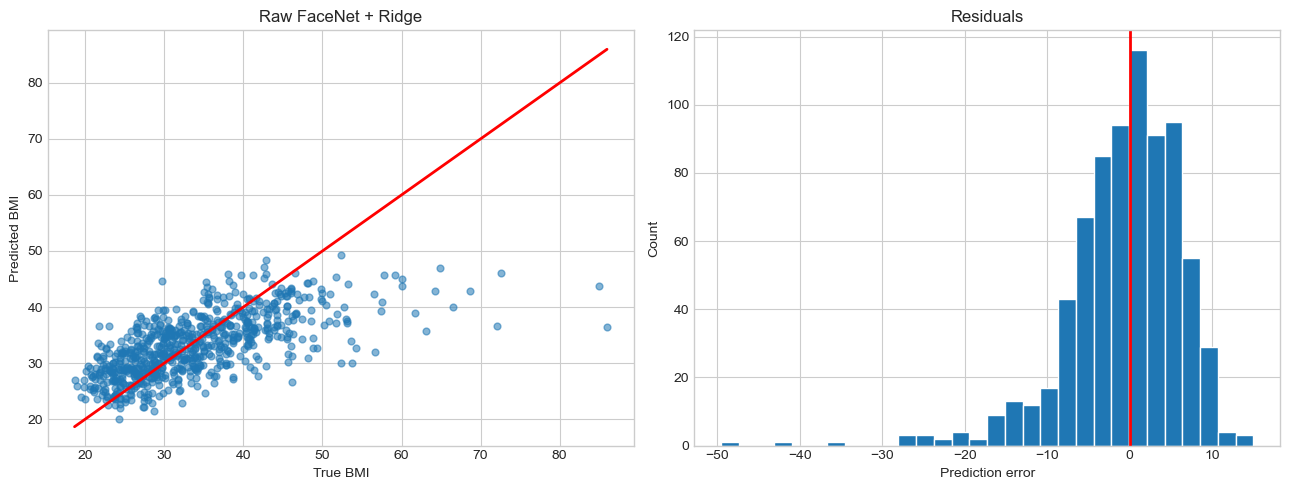

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(result_df["bmi"], result_df["pred"], alpha=0.55, s=24)
low = min(result_df["bmi"].min(), result_df["pred"].min())
high = max(result_df["bmi"].max(), result_df["pred"].max())
axes[0].plot([low, high], [low, high], color="red", linewidth=2)
axes[0].set_xlabel("True BMI")
axes[0].set_ylabel("Predicted BMI")
axes[0].set_title("Raw FaceNet + Ridge")

errors = result_df["pred"] - result_df["bmi"]
axes[1].hist(errors, bins=30, edgecolor="white")
axes[1].axvline(0, color="red", linewidth=2)
axes[1].set_xlabel("Prediction error")
axes[1].set_ylabel("Count")
axes[1].set_title("Residuals")

plt.tight_layout()
plt.show()

## 11. Save Final Artifacts

In [15]:
import joblib

artifact_suffix = "quick" if QUICK_RUN else "full"
model_path = MODEL_DIR / f"raw_facenet_ridge_final_{artifact_suffix}.joblib"
pred_path = OUTPUT_DIR / f"raw_facenet_ridge_predictions_{artifact_suffix}.csv"
metrics_path = OUTPUT_DIR / f"raw_facenet_ridge_metrics_{artifact_suffix}.json"

joblib.dump(ridge_model, model_path)
result_df.to_csv(pred_path, index=False)

summary = {
    "model": "Raw FaceNet + Ridge",
    "quick_run": QUICK_RUN,
    "use_gender_feature": USE_GENDER_FEATURE,
    "train_samples_used": int(len(train_used_df)),
    "test_samples_used": int(len(test_used_df)),
    "train_detection_failures": int(len(train_failed)),
    "test_detection_failures": int(len(test_failed)),
    "metrics_by_gender": metrics_by_gender.reset_index().to_dict(orient="records"),
}

with open(metrics_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved model:", model_path)
print("Saved predictions:", pred_path)
print("Saved metrics:", metrics_path)

Saved model: /Users/jiayingzhong/Desktop/ML_2/Final project/outputs/models/raw_facenet_ridge_final_full.joblib
Saved predictions: /Users/jiayingzhong/Desktop/ML_2/Final project/outputs/raw_facenet_ridge_predictions_full.csv
Saved metrics: /Users/jiayingzhong/Desktop/ML_2/Final project/outputs/raw_facenet_ridge_metrics_full.json


## 12. Final Report Summary

Use this wording in the report:

> The final model uses MTCNN for face detection and alignment, FaceNet/InceptionResnetV1 pretrained on VGGFace2 as a CNN-based facial feature extractor, and Ridge Regression to predict continuous BMI from the raw 512-dimensional facial embeddings. Gender is included as an auxiliary feature. The CNN is not trained from scratch; it is used for transfer learning to produce robust face embeddings, while the regression model learns the mapping from embeddings to BMI.